# Example Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/example_demo.ipynb)

This notebook demonstrates the standard pattern for documentation examples. Each example generates figures inline and lets the committed `.ipynb` cell outputs serve as the rendered docs.

**What you'll learn:**

1. How to set up a Colab-compatible notebook
2. How to generate and display figures inline
3. How to produce timing / statistics tables

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time

import matplotlib.pyplot as plt
import numpy as np

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,matplotlib,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

numpy     : 2.4.4
matplotlib: 3.10.8
xtremax : 0.1.5

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Setup

We create some sample data to plot.

In [4]:
x = np.linspace(0, 2 * np.pi, 200)
signals = {
    "sin(x)": np.sin(x),
    "sin(2x)": np.sin(2 * x),
    "sin(x) + 0.5 sin(3x)": np.sin(x) + 0.5 * np.sin(3 * x),
}

## Figures

Generate and display a comparison figure.

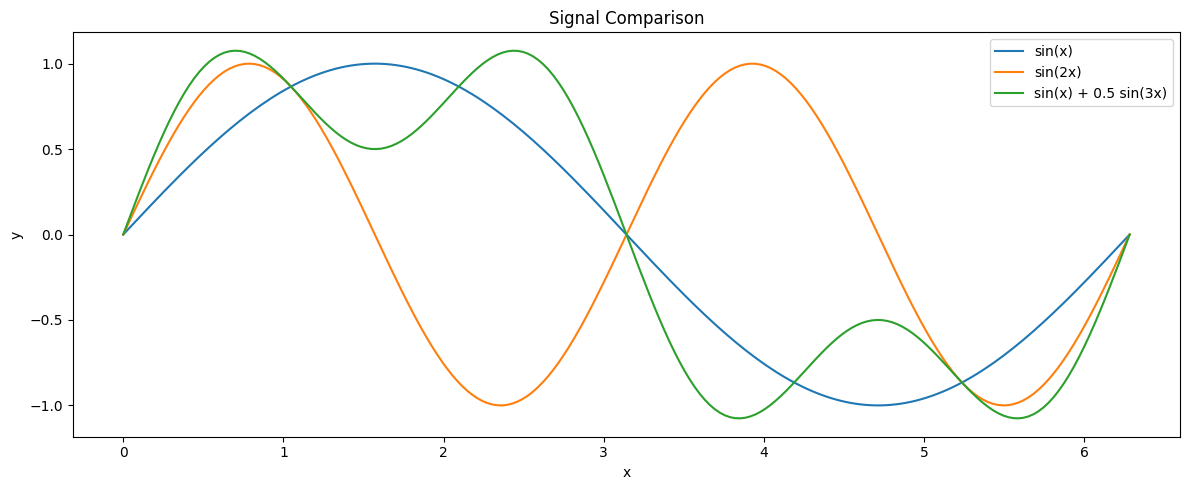

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, y in signals.items():
    ax.plot(x, y, label=label)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Signal Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## Timing & Statistics

Collect timing data, then present as printed output.

In [6]:
repeats = 1000
results: dict[str, dict] = {}
for label, y in signals.items():
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = np.fft.rfft(y)
    elapsed_ms = (time.perf_counter() - t0) * 1e3 / repeats
    rms = float(np.sqrt(np.mean(y**2)))
    results[label] = {"time_ms": elapsed_ms, "rms": rms}

print(f"{'Signal':30s}  {'Time (ms)':>10s}  {'RMS':>8s}")
print("-" * 52)
for label, stats in results.items():
    print(f"{label:30s}  {stats['time_ms']:10.4f}  {stats['rms']:8.4f}")

Signal                           Time (ms)       RMS
----------------------------------------------------
sin(x)                              0.0184    0.7053
sin(2x)                             0.0097    0.7053
sin(x) + 0.5 sin(3x)                0.0104    0.7886


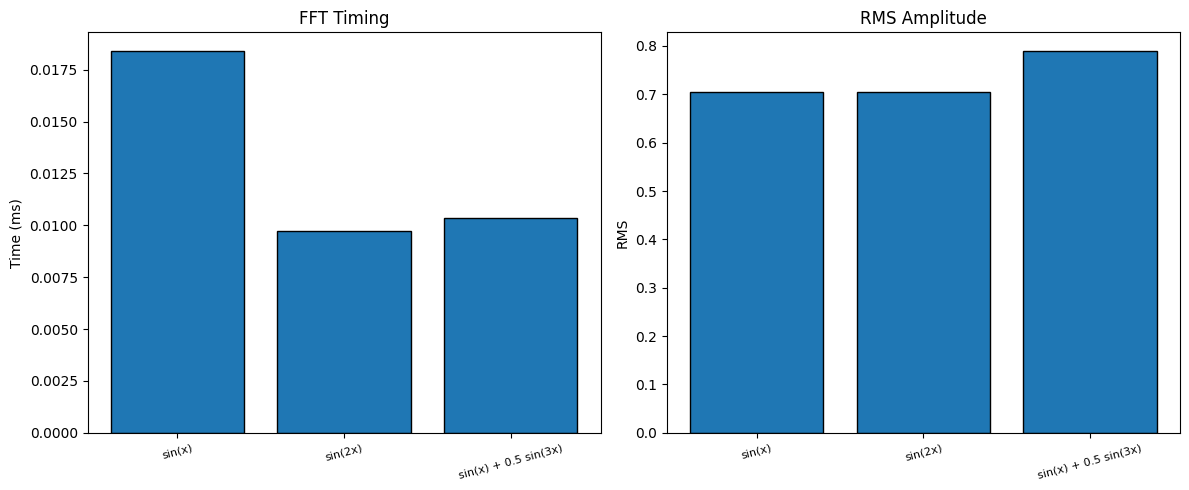

In [7]:
fig, (ax_time, ax_rms) = plt.subplots(1, 2, figsize=(12, 5))

labels = list(results.keys())
times = [results[k]["time_ms"] for k in labels]
rms_vals = [results[k]["rms"] for k in labels]

ax_time.bar(range(len(labels)), times, edgecolor="black")
ax_time.set_xticks(range(len(labels)))
ax_time.set_xticklabels(labels, fontsize=8, rotation=15)
ax_time.set_ylabel("Time (ms)")
ax_time.set_title("FFT Timing")

ax_rms.bar(range(len(labels)), rms_vals, edgecolor="black")
ax_rms.set_xticks(range(len(labels)))
ax_rms.set_xticklabels(labels, fontsize=8, rotation=15)
ax_rms.set_ylabel("RMS")
ax_rms.set_title("RMS Amplitude")

plt.tight_layout()
plt.show()

## Summary

This example showed the standard documentation pattern:

1. **Colab setup** — detect environment, install if needed
2. **Imports + watermark** — reproducibility readout
3. **Compute** — run the demonstration
4. **Display** — `plt.show()` embeds figures as cell outputs